# __НАЦИОНАЛЬНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ УНИВЕРСИТЕТ ИТМО__
## Факультет программной инженерии и компьютерных технологий
### _нейрофизиология_
### __Лабораторная работа №3__
---
__выполнили:__ Егорова Варвара, Набокова Алиса, Осинкина Анастасия,
Хижниченко Мария, Шилова Ярослава, Шнейдерис Герардас

__преподаватель:__ Билый Андрей Михайлович



г. Санкт-Петербург

2025

<!-- полный [отчет](https://docs.google.com/document/d/1EI9ICOiMcNRICA5t4kl5IpMqOcKTKCSm5gnH1veTIMM/edit?usp=sharing) -->

## подготовка окружения и загрузка данных

#### установка библиотек

In [ ]:
!pip install -q gdown # для модной загрузки данных
!pip install heartpy # по дефолту не установлен
!pip install biosppy # по дефолту не установлен
!pip install peakutils # по дефолту не установлен

#### импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# нейро штуки
import heartpy as hp
from scipy import signal
from scipy.signal import butter, filtfilt, welch
from biosppy.signals import ecg

# для загрузки файлов
from pathlib import Path
import gdown

# для модных таблиц
import re
from IPython.display import display, HTML
import numbers

#### загрузка данных с гугл диска

In [ ]:
%%time

def load_files(folder:str, dir: Path, separator: str) -> dict[str, pd.DataFrame]:
    # --- загружаем с гугл диска или используем кеш ---
    if dir.exists() and any(dir.glob("*.csv")):
        print("кэш найден — используем", dir)
    else:
        dir.mkdir(parents=True, exist_ok=True)
        print("скачиваем папку с Drive...")
        gdown.download_folder(folder, output=str(dir), quiet=False, use_cookies=False)
        print("готово — файлы в", dir)

    csv_paths = sorted(dir.rglob("*.csv"))
    print("найдены вот столько CSV файлов:", len(csv_paths))

    # словарь со всеми датафреймами (ключи — названия)
    return {p.stem: pd.read_csv(p, sep=separator, low_memory=False) for p in csv_paths}

BIO_FOLDER_URL = "https://drive.google.com/drive/folders/17flTLmUqUxMdrtRMPcGXvBilf7h3-vEd"
BIO_DATA_DIR = Path("/content/data_cached")

TEST_FOLDER_URL = "https://drive.google.com/drive/folders/1E-lliI7FicIZDo7k35KuIMK5WoEfI7nY"
TEST_DATA_DIR = Path("/content/test_data_cached")

dfs = load_files(BIO_FOLDER_URL, BIO_DATA_DIR, separator='\t')
test_dfs = load_files(TEST_FOLDER_URL, TEST_DATA_DIR, separator=',')

кэш найден — используем /content/data_cached
найдены вот столько CSV файлов: 6
кэш найден — используем /content/test_data_cached
найдены вот столько CSV файлов: 5
CPU times: user 14.3 s, sys: 2.21 s, total: 16.5 s
Wall time: 17 s


#### предобработка данных

In [ ]:
# --- предобработка данных BioRadio ---
bad_columns = ['ECG', 'EEGFR', 'EEGFL', 'EEGBR', 'EEGBL', 'EEGOR', 'EEGOL',
               'PPG pulse', 'Heart Rate pulse', 'SpO2 pulse']

for name, df in dfs.items():
    df = df.drop(columns=['Unnamed: 10', 'BioRadio Event'], errors='ignore')

    for col in bad_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.replace(r'\s+', '', regex=True)
            df[col] = df[col].str.replace(',', '.', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce')

    dfs[name] = df

if 'nastya' in dfs: dfs.pop('nastya') # настины данные не записались из-за проблем с подключением
if 'gera' in dfs: dfs.pop('gera') # gera и masha получились дубликатми из-за ошибки с файлами

#### агрегация

сагрегируем данные с BioRadio посекундно и разделим на 5 участков:


1.   фон - 2 минуты
2.   нагрузка 1 - 5 минут
3.   нагрузка 2 - 5 минут
4.   нагрузка 3 - 5 минут
5.   покой - 5 минут

(нагрузка 1, 2 и 3 отличаются объемом передаваемой информации)

In [ ]:
fs = 250 # частота BioRadio
test_start, test_part_duration = 2 * 60, 5 * 60
raw_data, data = {}, {}

# парсит временную метку для аггрегации
def time_to_seconds(time_str):
    h, m, s = time_str.split(':')
    return int(h) * 3600 + int(m) * 60 + int(float(s))

for name, df in dfs.items():
    df['seconds'] = df['Elapsed Time'].apply(time_to_seconds)

    # разделение датафрейма
    raw_data[f"{name}_1"] = df[df['seconds'] < test_start].copy()
    raw_data[f"{name}_2"] = df[
        (df['seconds'] >= test_start) & (df['seconds'] < test_part_duration * 1)
    ].copy()
    raw_data[f"{name}_3"] = df[
        (df['seconds'] >= test_part_duration * 1) & (df['seconds'] < test_part_duration * 2)
    ].copy()
    raw_data[f"{name}_4"] = df[
        (df['seconds'] >= test_part_duration * 2) & (df['seconds'] < test_part_duration * 3)
    ].copy()
    raw_data[f"{name}_5"] = df[df['seconds'] >= test_part_duration * 3].copy()

    # аггрегация посекундно
    for i in range(1, 6):
        data[f"{name}_{i}"] = raw_data[f"{name}_{i}"].groupby(raw_data[f"{name}_{i}"]['seconds']).mean(numeric_only=True).reset_index()

for name, df in data.items():
    print(name, df.shape)

alice_1 (60000, 10)
alice_2 (90000, 10)
alice_3 (150000, 10)
alice_4 (150000, 10)
alice_5 (145874, 10)
masha_1 (60000, 10)
masha_2 (90000, 10)
masha_3 (150000, 10)
masha_4 (150000, 10)
masha_5 (152318, 10)
varya_1 (60000, 10)
varya_2 (90000, 10)
varya_3 (150000, 10)
varya_4 (150000, 10)
varya_5 (134124, 10)
yara_1 (60000, 10)
yara_2 (90000, 10)
yara_3 (150000, 10)
yara_4 (150000, 10)
yara_5 (145316, 10)
alice_1 (120, 9)
alice_2 (180, 9)
alice_3 (300, 9)
alice_4 (300, 9)
alice_5 (292, 9)
masha_1 (120, 9)
masha_2 (180, 9)
masha_3 (300, 9)
masha_4 (300, 9)
masha_5 (305, 9)
varya_1 (120, 9)
varya_2 (180, 9)
varya_3 (300, 9)
varya_4 (300, 9)
varya_5 (269, 9)
yara_1 (120, 9)
yara_2 (180, 9)
yara_3 (300, 9)
yara_4 (300, 9)
yara_5 (291, 9)


#### вспомогательные функции

In [ ]:
def decor(title: str, width: int) -> str:
    return f'{width * "="} {title} {width * "="}\n' # для красоты

def _is_number(x):
    return isinstance(x, numbers.Number) # надо

## физиологические показатели (ЛР 1)

#### функции для вывода таблиц

In [ ]:
# группирует данные с разных участков по респондентам
def group_flat_data_simple(data_flat):
    groups = {}
    for k, v in data_flat.items():
        m = re.compile(r'^(?P<base>.+?)_([12345])$').match(k)
        groups.setdefault(m.group('base'), [None, None, None, None, None])[int(m.group(2)) - 1] = v
    return groups

# собирает из данных таблицу для респондента
def build_table_for_respondent(dfs3, analyzer):
    cols = pd.MultiIndex.from_product([['фон до', 'нагрузка 1', 'нагрузка 2', 'нагрузка 3', 'фон после'],
        ['min', 'max', 'mean', 'std']])
    row = []
    for df in dfs3:
        row.extend(analyzer(df))
    return pd.DataFrame([row], columns=cols)

# в ээг анализе больше данных и другой формат
def build_eeg_table_for_respondent(dfs3, analyzer):
    parts = ['фон до', 'нагрузка 1', 'нагрузка 2', 'нагрузка 3', 'фон после']
    results = [{ch: (p_a, p_b, r) for ch, p_a, p_b, r in analyzer(df)} for df in dfs3]
    channels = list(results[0].keys()) if results and results[0] else sorted({c for d in results for c in d})
    table = pd.DataFrame(index=channels, columns=pd.MultiIndex.from_product([parts, ['p_α', 'p_β', 'α/β']]), dtype=float)
    for i, part in enumerate(parts):
        for ch in channels:
            vals = results[i].get(ch)
            table.loc[ch, (part, 'p_α')] = vals[0] if vals else np.nan
            table.loc[ch, (part, 'p_β')] = vals[1] if vals else np.nan
            table.loc[ch, (part, 'α/β')] = vals[2] if vals else np.nan
    return table

# собирает общую таблицу
def make_final_table(data_flat, analyzer, channels=False):
    groups = group_flat_data_simple(data_flat)
    per_respondent, names = [], []
    for name, dfs3 in groups.items():
        per_respondent.append(
            build_eeg_table_for_respondent(dfs3, analyzer) if channels
            else build_table_for_respondent(dfs3, analyzer)
            )
        names.append(name)
    return pd.concat(per_respondent, keys=names, names=['респондент', 'канал'])

# ------------------------ стили и отображение ------------------------
TABLE_STYLES = [
    {'selector': 'td', 'props': [('padding', '6px'), ('vertical-align', 'middle'), ('border-right', '1px solid #666')]},
    {'selector': 'th.col_heading.level1', 'props': [('padding', '6px'), ('text-align', 'center'), ('border-right', '1px solid #666')]},
    {'selector': 'th.col_heading.level0', 'props': [('padding', '8px'), ('text-align', 'center'), ('font-weight', '600'), ('border-right', '3px solid #444')]},
]

def _channel_bg_style(channel_name):
    return f"background-color: hsl({abs(hash(channel_name)) % 360}deg 50% 88%); color: #000;"

def color_row_by_channel(row):
    return [_channel_bg_style(row.name[1] if isinstance(row.name, tuple) and len(row.name) > 1 else str(row.name)) for _ in row]

def _apply_styles(styler, float_fmt="{:.5e}"):
    return styler.format(lambda v: float_fmt.format(v) if pd.notna(v) else "").set_table_styles(TABLE_STYLES)

def show(final_df, float_fmt="{:.5e}"):
    display(_apply_styles(final_df.droplevel(level=1).style, float_fmt))

def show_eeg(final_df, float_fmt="{:.5e}", na_str="-"):
    styler = final_df.style.apply(color_row_by_channel, axis=1)
    styler = styler.format(
        lambda v: na_str if pd.isna(v) else float_fmt.format(v)
    )
    styler = styler.set_table_styles(TABLE_STYLES)
    display(styler)

#### функции для расчета показателей

In [ ]:
fs = 250
eeg_cols = ['EEGFR', 'EEGFL', 'EEGOR', 'EEGOL']

def band_power(signal, fs, band, nperseg=1024):
    # Вычисление мощности в заданной полосе частот через методом Уэлча
    f, Pxx = welch(signal, fs=fs, nperseg=min(nperseg, len(signal)))
    idx = (f >= band[0]) & (f < band[1])
    return np.trapezoid(Pxx[idx], f[idx]) if np.any(idx) else 0.0

alpha_band = (8, 13)
beta_band = (13, 30)

def eeg_rhythms_analyze(df: pd.DataFrame) -> list:
    eeg_channels = [c for c in df.columns if c.startswith('EEG')] # убрала хардкод каналов
    return [
        (ch, P_alpha, P_beta, np.nan if P_beta == 0 else P_alpha / P_beta)
        for ch in list(filter(lambda ch: ch in df.columns, eeg_channels))
        for sig in [pd.to_numeric(df[ch], errors='coerce').dropna().to_numpy()]
        if len(sig) > 0
        for P_alpha in [band_power(sig, fs, alpha_band)]
        for P_beta in [band_power(sig, fs, beta_band)]
    ]

def series_stats(row: pd.Series) -> tuple:
    num_row = pd.to_numeric(row, errors='coerce').dropna()
    if num_row.empty: return np.nan, np.nan, np.nan, np.nan
    return num_row.min(), num_row.max(), num_row.mean(), num_row.std()

def bpm_analyze(df: pd.DataFrame) -> tuple:
    return series_stats(df['Heart Rate pulse'])

def spo2_analyze(df: pd.DataFrame) -> tuple:
    return series_stats(df['SpO2 pulse'])

# ВСР

def bandpass_filter(signal_data, lowcut, highcut, fs: int):
    nyq = 0.5 * fs
    b, a = signal.butter(2, [lowcut / nyq, highcut / nyq], btype='band')
    return signal.filtfilt(b, a, signal_data)

def compute_baevsky_index(rr_intervals):
    hist, bin_edges = np.histogram(np.sort(rr_intervals), bins=50)
    Mo_index = np.argmax(hist)
    Mo = (bin_edges[Mo_index] + bin_edges[Mo_index + 1]) / 2
    AMo = hist[Mo_index] / len(rr_intervals) * 100
    MxDMn = np.max(rr_intervals) - np.min(rr_intervals)

    if Mo * MxDMn == 0: return np.nan
    return AMo / (2 * Mo * MxDMn) * 1e6  # масштабируем

def compute_frequency_domain(rr_intervals, fs=4.0) -> dict:
    # интерполяция RR для равномерной сетки
    time = np.cumsum(rr_intervals) / 1000.0
    time -= time[0] # сдвиг к нулю
    f_interp = np.interp(np.arange(0, time[-1], 1/fs), time, rr_intervals)
    f_interp -= np.mean(f_interp)

    freqs, psd = signal.welch(f_interp, fs=fs, nperseg=len(f_interp)//2)

    # диапазоны
    def _band_power(fmin, fmax):
        mask = (freqs >= fmin) & (freqs < fmax)
        return np.trapezoid(psd[mask], freqs[mask])

    vlf = _band_power(0.003, 0.04)
    lf = _band_power(0.04, 0.15)
    hf = _band_power(0.15, 0.4)
    ulf = _band_power(0.0, 0.003)
    total_power = vlf + lf + hf + ulf
    lf_hf = lf / hf if hf > 0 else np.nan

    return {'ULF': ulf, 'VLF': vlf, 'LF': lf, 'HF': hf, 'LF/HF': lf_hf, 'Total': total_power}

def ecg_analyze(df: pd.DataFrame):
    ecg_data = df['ECG'].astype(float).values
    ecg_data = ecg_data[np.isfinite(ecg_data)]
    ecg_data = bandpass_filter(ecg_data, 0.5, 40, 250)

    out = ecg.ecg(signal=ecg_data, sampling_rate=250, show=False)
    rr_intervals = np.diff(out['rpeaks']) / 250 * 1000  # RR в мс

    # временные показатели
    sdnn = np.std(rr_intervals)
    rmssd = np.sqrt(np.mean(np.diff(rr_intervals)**2))

    # частотные показатели
    freq = compute_frequency_domain(rr_intervals)
    si = compute_baevsky_index(rr_intervals)

    return freq, si

#### Альфа и бета ритмы

In [ ]:
print(decor('анализ данных по альфа и бета ритмам ЭЭГ', 30))
show_eeg(make_final_table(data, eeg_rhythms_analyze, channels=True), float_fmt="{:.5e}")

============================== анализ данных по альфа и бета ритмам ЭЭГ ==============================



#### ЧСС

In [ ]:
print(decor('анализ данных о ЧСС', 35))
show(make_final_table(data, bpm_analyze), float_fmt="{:.2f}")

=================================== анализ данных о ЧСС ===================================



#### оксигенация

In [ ]:
print(decor('анализ данных об уровне оксигенации', 24))
show(make_final_table(data, spo2_analyze), float_fmt="{:.2f}")

======================== анализ данных об уровне оксигенации ========================



#### ВСР

In [ ]:
#ECG
print(decor('анализ показателей вариативности сердечного ритма', 35))
for name, df in raw_data.items():
    print(f"\n{name}")

    freq, si = ecg_analyze(df)

    print(f"ULF: {freq['ULF']:.2f}, VLF: {freq['VLF']:.2f}, LF: {freq['LF']:.2f}, HF: {freq['HF']:.2f}, LF/HF: {freq['LF/HF']:.2f}")
    print(f"Total Power (VSR): {freq['Total']:.2f}")
    print(f"Индекс напряжения по Баевскому (SI): {si:.2f}")

анализ показателей вариативности сердечного ритма

alice_1
ULF: 0.00, VLF: 3686.26, LF: 3968.82, HF: 115.17, LF/HF: 34.46
Total Power (VSR): 7770.26
Индекс напряжения по Баевскому (SI): 4.87

alice_2
ULF: 0.00, VLF: 5092.65, LF: 1857.45, HF: 222.19, LF/HF: 8.36
Total Power (VSR): 7172.29
Индекс напряжения по Баевскому (SI): 6.56

alice_3
ULF: 0.00, VLF: 5685.48, LF: 4534.66, HF: 215.52, LF/HF: 21.04
Total Power (VSR): 10435.67
Индекс напряжения по Баевскому (SI): 3.15

alice_4
ULF: 0.00, VLF: 4950.13, LF: 5113.25, HF: 877.26, LF/HF: 5.83
Total Power (VSR): 10940.65
Индекс напряжения по Баевскому (SI): 3.15

alice_5
ULF: 0.00, VLF: 4964.90, LF: 4334.11, HF: 151.53, LF/HF: 28.60
Total Power (VSR): 9450.54
Индекс напряжения по Баевскому (SI): 4.54

masha_1
ULF: 0.00, VLF: 112.44, LF: 109.72, HF: 16.19, LF/HF: 6.78
Total Power (VSR): 238.34
Индекс напряжения по Баевскому (SI): 37.87

masha_2
ULF: 0.00, VLF: 3282.01, LF: 1109.61, HF: 329.87, LF/HF: 3.36
Total Power (VSR): 4721.48
Индекс нап

In [ ]:
from IPython.display import HTML, display
import pandas as pd

# Заголовок
print("Анализ показателей вариативности сердечного ритма".center(60))

# Собираем результаты
results = []
for name, df in raw_data.items():
    freq, si = ecg_analyze(df)
    results.append({
        'Пациент / Сегмент': name,
        'ULF': f"{freq['ULF']:.2f}",
        'VLF': f"{freq['VLF']:.2f}",
        'LF':  f"{freq['LF']:.2f}",
        'HF':  f"{freq['HF']:.2f}",
        'LF/HF': f"{freq['LF/HF']:.2f}",
        'Total Power (VSR)': f"{freq['Total']:.2f}",
        'SI (Баевский)': f"{si:.2f}"
    })

# DataFrame → HTML
df_results = pd.DataFrame(results)

# Простая таблица: минимум CSS
html = """
<style>
  .simple-table {
    width: 100%;
    max-width: 900px;
    margin: 20px auto;
    border-collapse: collapse;
    font-family: Arial, sans-serif;
    font-size: 14px;
  }
  .simple-table th {
    background-color: #f0f0f0;
    padding: 10px;
    text-align: center;
    border: 1px solid #ddd;
  }
  .simple-table td {
    padding: 8px 10px;
    text-align: center;
    border: 1px solid #ddd;
  }
  .simple-table tr:nth-child(even) {
    background-color: #f9f9f9;
  }
</style>

<table class="simple-table">
""" + df_results.to_html(index=False, border=0) + "</table>"

display(HTML(html))

     Анализ показателей вариативности сердечного ритма      


Пациент / Сегмент,ULF,VLF,LF,HF,LF/HF,Total Power (VSR),SI (Баевский)
alice_1,0.00,3686.26,3968.82,115.17,34.46,7770.26,4.87
alice_2,0.00,5092.65,1857.45,222.19,8.36,7172.29,6.56
alice_3,0.00,5685.48,4534.66,215.52,21.04,10435.67,3.15
alice_4,0.00,4950.13,5113.25,877.26,5.83,10940.65,3.15
alice_5,0.00,4964.90,4334.11,151.53,28.60,9450.54,4.54
masha_1,0.00,112.44,109.72,16.19,6.78,238.34,37.87
masha_2,0.00,3282.01,1109.61,329.87,3.36,4721.48,10.28
masha_3,0.00,4102.09,5067.61,2498.56,2.03,11668.26,7.18
masha_4,0.00,1469.56,2842.77,1101.90,2.58,5414.23,9.91
masha_5,0.00,1779.87,1900.45,580.52,3.27,4260.84,7.71


In [ ]:
print(decor('анализ показателей вариативности сердечного ритма по ФПГ', 35))
for name, df in raw_data.items():
    print(f"\n{name}")
    ppg_data = df['PPG pulse'].astype(str).str.replace(',', '.').astype(float).values
    ppg_data = ppg_data[np.isfinite(ppg_data)]
    ppg_data = bandpass_filter(ppg_data, 0.5, 8, 100)  # PPG: ниже частоты, fs=100Hz

    try:
        # Детекция пиков PPG (аналог R-пиков в ЭКГ)
        peaks, _ = signal.find_peaks(ppg_data, distance=0.5*100, prominence=np.std(ppg_data)*0.3)
        rr_intervals = np.diff(peaks) / 100 * 1000  # PP-интервалы в мс

        if len(rr_intervals) < 5:
            raise ValueError("мало пиков для анализа")

        # Частотные показатели
        freq = compute_frequency_domain(rr_intervals)
        si = compute_baevsky_index(rr_intervals)

        print(f"ULF: {freq['ULF']:.2f}, VLF: {freq['VLF']:.2f}, LF: {freq['LF']:.2f}, HF: {freq['HF']:.2f}, LF/HF: {freq['LF/HF']:.2f}")
        print(f"Total Power (VSR): {freq['Total']:.2f}")
        print(f"Индекс напряжения по Баевскому (SI): {si:.2f}")

    except Exception as e:
        print(f"ошибка у {name}: {e}")

=================================== анализ показателей вариативности сердечного ритма по ФПГ ===================================


alice
ULF: 4604.40, VLF: 10650.96, LF: 10392.30, HF: 13217.08, LF/HF: 0.79
Total Power (VSR): 38864.74
Индекс напряжения по Баевскому (SI): 2.27

masha
ULF: 1980.57, VLF: 9487.02, LF: 11694.24, HF: 11285.57, LF/HF: 1.04
Total Power (VSR): 34447.39
Индекс напряжения по Баевскому (SI): 2.53

varya
ULF: 1231.51, VLF: 2737.72, LF: 817.95, HF: 2475.32, LF/HF: 0.33
Total Power (VSR): 7262.50
Индекс напряжения по Баевскому (SI): 2.81

yara
ULF: 2375.15, VLF: 10519.19, LF: 2034.55, HF: 3101.44, LF/HF: 0.66
Total Power (VSR): 18030.34
Индекс напряжения по Баевскому (SI): 4.84


In [ ]:
from IPython.display import HTML, display
import pandas as pd
import numpy as np
from scipy import signal

def decor(text, length=35):
    return f"{text}".center(length, " ")

print(decor('анализ показателей вариативности сердечного ритма по ФПГ', 60))

results = []

for name, df in raw_data.items():
    try:
        ppg_data = df['PPG pulse'].astype(str).str.replace(',', '.').astype(float).values
        ppg_data = ppg_data[np.isfinite(ppg_data)]
        ppg_data = bandpass_filter(ppg_data, 0.5, 8, 100)  # fs=100 Hz

        peaks, _ = signal.find_peaks(ppg_data, distance=0.5*100, prominence=np.std(ppg_data)*0.3)
        rr_intervals = np.diff(peaks) / 100 * 1000  # в мс

        if len(rr_intervals) < 5:
            raise ValueError("мало пиков для анализа")

        freq = compute_frequency_domain(rr_intervals)
        si = compute_baevsky_index(rr_intervals)

        results.append({
            'Пациент / Сегмент': name,
            'ULF': f"{freq['ULF']:.2f}",
            'VLF': f"{freq['VLF']:.2f}",
            'LF':  f"{freq['LF']:.2f}",
            'HF':  f"{freq['HF']:.2f}",
            'LF/HF': f"{freq['LF/HF']:.2f}",
            'Total Power (VSR)': f"{freq['Total']:.2f}",
            'SI (Баевский)': f"{si:.2f}"
        })

    except Exception as e:
        results.append({
            'Пациент / Сегмент': name,
            'ULF': '—',
            'VLF': '—',
            'LF':  '—',
            'HF':  '—',
            'LF/HF': '—',
            'Total Power (VSR)': '—',
            'SI (Баевский)': f'Ошибка: {e}'
        })

df_results = pd.DataFrame(results)

html = """
<style>
  .simple-table {
    width: 100%;
    max-width: 950px;
    margin: 20px auto;
    border-collapse: collapse;
    font-family: Arial, sans-serif;
    font-size: 14px;
  }
  .simple-table th {
    background-color: #f0f0f0;
    padding: 10px;
    text-align: center;
    border: 1px solid #ddd;
    font-weight: 600;
  }
  .simple-table td {
    padding: 8px 10px;
    text-align: center;
    border: 1px solid #ddd;
  }
  .simple-table tr:nth-child(even) {
    background-color: #f9f9f9;
  }
  .error-row {
    color: #d9534f;
    font-style: italic;
  }
</style>

<table class="simple-table">
""" + df_results.to_html(index=False, border=0, escape=False) + "</table>"

html = html.replace('Ошибка:', '<span class="error-row">Ошибка:</span>')

display(HTML(html))

  анализ показателей вариативности сердечного ритма по ФПГ  


Пациент / Сегмент,ULF,VLF,LF,HF,LF/HF,Total Power (VSR),SI (Баевский)
alice_1,0.00,13137.87,1566.70,8741.67,0.18,23446.24,4.45
alice_2,834.18,6978.57,12710.36,13589.51,0.94,34112.63,2.13
alice_3,3711.86,10287.63,13730.50,14082.32,0.98,41812.30,2.04
alice_4,1997.87,7330.80,4245.93,8002.46,0.53,21577.06,3.10
alice_5,1590.29,12270.71,4296.04,10510.05,0.41,28667.10,3.22
masha_1,0.00,453.93,240.20,955.13,0.25,1649.26,5.60
masha_2,986.50,12629.48,18960.09,12114.35,1.57,44690.41,2.30
masha_3,737.14,8867.11,6033.67,5356.02,1.13,20993.94,2.07
masha_4,317.82,5746.97,10434.58,12694.07,0.82,29193.44,1.92
masha_5,268.41,4813.32,2423.81,4928.46,0.49,12433.99,2.83


## ЛР3

#### небольшие расчеты

немного о данных полученых от интерактивного теста:
- `errors`: событие, когда пользователь нажал на неверную кнопку или невовремя
- `hits`: событие, когда пользователь вовремя нажал нужную кнопку
- `counts`: число полных оборотов круга
- `misses`: событие, когда пользователь пропустил момент для нажатия

__NB1:__ постфиксы `_left`, `_center` и `_right` означают, что значение параметра расчитывалось для левого, центарльного или правого круга соответственно.

__NB2:__ интерактивный тест считает все параметры в аккумулятивном режиме т.е. `errors` в каждый конкретный момент показывает количество ошибок совершенных за все время прохождения теста, поэтому для столбцов `errors`, `hits`, `counts` и `misses` были также расчитаны (см. код ниже) столбцы с постфиксами `_per_{window}_sec` (`window` - размер окна в секундах, можно настраивать) отображающие соответственно изменение значение параметра за последние `window` секунд

In [ ]:
window = 20

for name, df in test_dfs.items():
    df['misses_left'] = df['counts_left'] - df['hits_left']
    df['misses_center'] = df['counts_center'] - df['hits_center']
    df['misses_right'] = df['counts_right'] - df['hits_right']

    df['hits'] = df['hits_left'] + df['hits_center'] + df['hits_right']
    df['counts'] = df['counts_left'] + df['counts_center'] + df['counts_right']
    df['misses'] = df['misses_left'] + df['misses_center'] + df['misses_right']

    df[f'errors_per_{window}_sec'] = df['errors'] - df['errors'].shift(window)
    df[f'hits_per_{window}_sec'] = df['hits'] - df['hits'].shift(window)
    df[f'misses_per_{window}_sec'] = df['misses'] - df['misses'].shift(window)
    df[f'counts_per_{window}_sec'] = df['counts'] - df['counts'].shift(window)
    df.fillna(0)

    test_dfs[name] = df

## Попробуем найти взаимосвязь напряжения и результатов теста

### смерджим dfs и test_dfs по секундам

In [ ]:
merged_dfs = {}

# Имена людей, которые есть в обоих наборах данных
common_names = set(dfs.keys()) & set(test_dfs.keys())

for name in common_names:
    # Берем физиологические данные
    physio_df = data[f"{name}_2"].copy() # Нас интересует этап "нагрузка"
    physio_df.set_index('seconds', inplace=True)

    # Берем данные теста
    test_df = test_dfs[name].copy()
    test_df.index.name = 'seconds' # Убедимся, что имя индекса то же самое

    # Объединяем. 'how="inner"' гарантирует, что останутся только общие секунды.
    merged_df = pd.merge(physio_df, test_df, left_index=True, right_index=True, how='inner')

    merged_dfs[name] = merged_df

# Проверим результат для одного человека
print("Объединенные данные для 'masha':")
print(merged_dfs['masha'].head())

Объединенные данные для 'masha':
          EEGFR   EEGFL     EEGBR     EEGBL       ECG  Heart Rate pulse  \
seconds                                                                   
120     -0.1875 -0.1875 -0.186121 -0.185210 -0.015110           114.000   
121     -0.1875 -0.1875 -0.186241 -0.185298 -0.015120           113.104   
122     -0.1875 -0.1875 -0.186274 -0.185352 -0.014683           112.768   
123     -0.1875 -0.1875 -0.186339 -0.185438 -0.016787           112.000   
124     -0.1875 -0.1875 -0.186552 -0.185052 -0.017341           110.208   

         PPG pulse  SpO2 pulse      timestamp  errors  ...  misses_left  \
seconds                                                ...                
120      80.030908      95.104  1764766745647      40  ...            8   
121      81.338145      95.000  1764766746647      42  ...            8   
122      79.764333      95.000  1764766747647      42  ...            9   
123      78.162579      95.000  1764766748647      42  ...        

### Расчет динамических физиологических показателей

In [ ]:
def get_rr_intervals_from_ppg_window(ppg_signal, fs):
    peaks, _ = signal.find_peaks(bandpass_filter(ppg_signal, 0.5, 8, fs), distance=int(0.5*fs))

    # PP-интервалы в мс
    return np.diff(peaks) / fs * 1000

In [ ]:
fs = 250  # Частота дискретизации BioRadio
window_size_sec = 60
window_size_samples = window_size_sec * fs  # Размер окна в сэмплах

# Словарь для хранения результатов
rmssd_results = {}

for name, raw_df in dfs.items():
    print(f"Обрабатываем {name} из dfs...")

    ppg_signal = pd.to_numeric(raw_df['PPG pulse'], errors='coerce').dropna().values

    rmssd_values = []
    time_stamps_sec = []

    for i in range(window_size_samples, len(ppg_signal), fs):
        window = ppg_signal[i - window_size_samples:i]

        rr_intervals = get_rr_intervals_from_ppg_window(window, fs=fs)

        if len(rr_intervals) < 5: rmssd_values.append(np.nan)
        else: rmssd_values.append(np.sqrt(np.mean(np.diff(rr_intervals)**2))) # Расчет RMSSD

        # Записываем временную метку (конец окна в секундах)
        current_second = (i // fs) - 1
        time_stamps_sec.append(current_second)

    # Создаем Series с результатами
    rmssd_series = pd.Series(rmssd_values, index=time_stamps_sec)
    rmssd_results[name] = rmssd_series
    print(f"Готово для {name}. Рассчитано {len(rmssd_values)} значений.")


# добавим эти правильные результаты в наши объединенные датафреймы
for name, df in merged_dfs.items():
    if name in rmssd_results:
        df['RMSSD_60s'] = rmssd_results[name]
        print(f"RMSSD добавлен в merged_dfs для {name}")

Обрабатываем alice из dfs...
Готово для alice. Рассчитано 2324 значений.
Обрабатываем masha из dfs...
Готово для masha. Рассчитано 2349 значений.
Обрабатываем varya из dfs...
Готово для varya. Рассчитано 2185 значений.
Обрабатываем yara из dfs...
Готово для yara. Рассчитано 2322 значений.
RMSSD добавлен в merged_dfs для alice
RMSSD добавлен в merged_dfs для yara
RMSSD добавлен в merged_dfs для varya
RMSSD добавлен в merged_dfs для masha


### Визуализируем

смотрим как менялись ошибки и уровень напряжения

In [ ]:
import matplotlib.pyplot as plt

window = 20

# Вот здесь меняете на нужного персона и смотрите графики
person = 'varya'
df = merged_dfs[person].fillna(0)

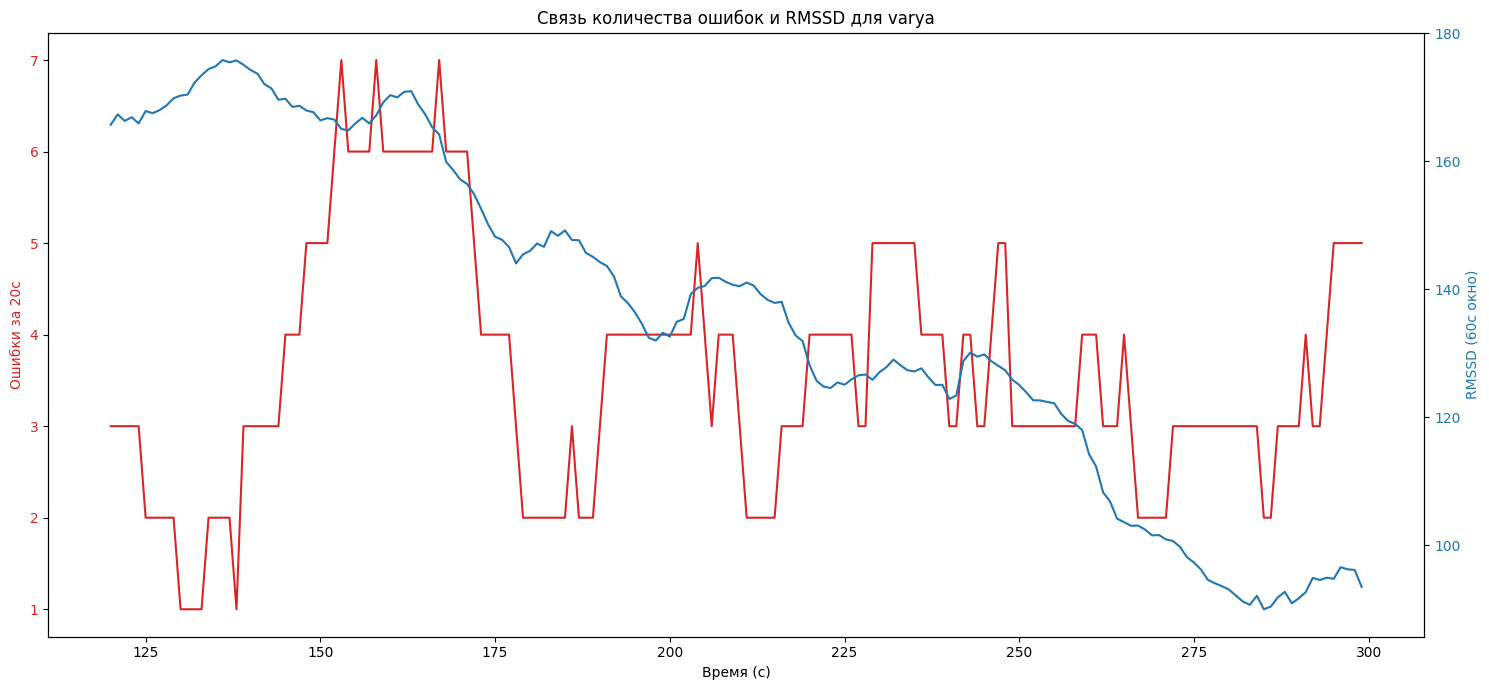

In [ ]:
window = 20

if f'errors_per_{window}_sec' not in df.columns or 'RMSSD_60s' not in df.columns:
    print(f"Ошибка: в датафрейме для {person} отсутствуют нужные столбцы.")
    print(f"Ищем столбцы: {f'errors_per_{window}_sec'} и 'RMSSD_60s'")
    print("Доступные столбцы:", df.columns)
else:
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # График ошибок (левая ось Y)
    color = 'tab:red'
    ax1.set_xlabel('Время (с)')
    ax1.set_ylabel('Ошибки за 20с', color=color)
    ax1.plot(df.index, df[f'errors_per_{window}_sec'], color=color, label='Ошибки')
    ax1.tick_params(axis='y', labelcolor=color)

    # Создаем вторую ось Y для физиологического показателя
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('RMSSD (60с окно)', color=color)
    ax2.plot(df.index, df['RMSSD_60s'], color=color, label='RMSSD')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Связь количества ошибок и RMSSD для {person}')
    fig.tight_layout()
    plt.show()

попробуем то же самое для попаданий

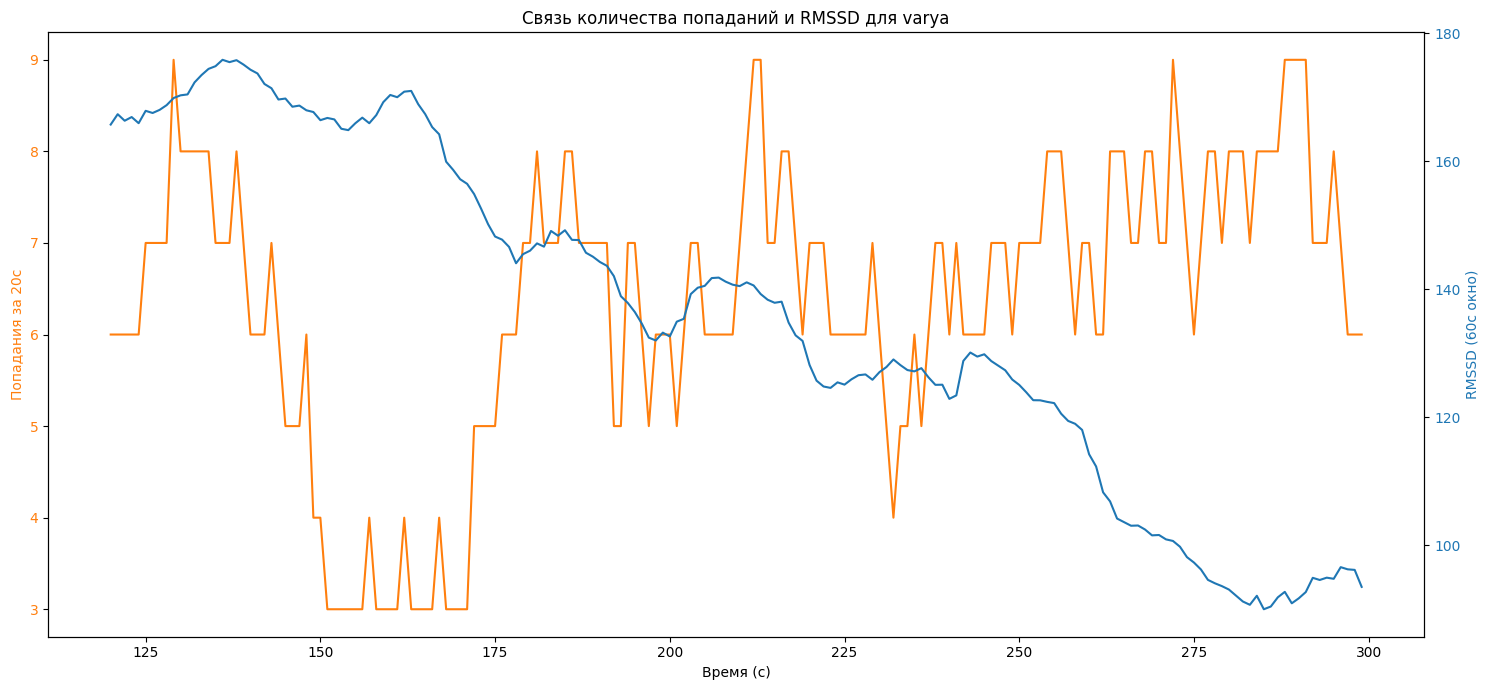

In [ ]:
window = 20

if f'hits_per_{window}_sec' not in df.columns or 'RMSSD_60s' not in df.columns:
    print(f"Ошибка: в датафрейме для {person} отсутствуют нужные столбцы.")
    print(f"Ищем столбцы: {f'hits_per_{window}_sec'} и 'RMSSD_60s'")
    print("Доступные столбцы:", df.columns)
else:
    fig, ax1 = plt.subplots(figsize=(15, 7))

    color = 'tab:orange'
    ax1.set_xlabel('Время (с)')
    ax1.set_ylabel('Попадания за 20с', color=color)
    ax1.plot(df.index, df[f'hits_per_{window}_sec'], color=color, label='Попадания')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('RMSSD (60с окно)', color=color)
    ax2.plot(df.index, df['RMSSD_60s'], color=color, label='RMSSD')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Связь количества попаданий и RMSSD для {person}')
    fig.tight_layout()
    plt.show()